# Data Analysis

## Objective
Analyze cleaned e-commerce data to extract meaningful insights related to:

- Customer behavior
- Sales performance
- Delivery performance
- Product trends
- Payment behavior

**Input:** Cleaned datasets  
**Output:** Business insights + visualizations

<hr>

## Import 

In [15]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<hr>

## Load Cleaned Data

In [16]:
base_path = r"D:\Ayush\Learning\Projects\Ecommerce\data\cleaned\\"

customers = pd.read_csv(base_path + "customers_cleaned.csv")
orders = pd.read_csv(base_path + "orders_cleaned.csv")
order_items = pd.read_csv(base_path + "order_items_cleaned.csv")
payments = pd.read_csv(base_path + "payments_cleaned.csv")
reviews = pd.read_csv(base_path + "reviews_cleaned.csv")
products = pd.read_csv(base_path + "products_cleaned.csv")
sellers = pd.read_csv(base_path + "sellers_cleaned.csv")

print("***All datasets loaded successfully!***")

***All datasets loaded successfully!***


<hr>

## Merge Cell

In [17]:
# Orders + Order Items
df = orders.merge(order_items, on="order_id", how="left")

# Add Payments
df = df.merge(payments, on="order_id", how="left")

# Add Customers
df = df.merge(customers, on="customer_id", how="left")

# Add Products
df = df.merge(products, on="product_id", how="left")

# Processed data
df.to_csv(r"D:\Ayush\Learning\Projects\Ecommerce\data\processed\final_dataset.csv", index=False)
print("Saved")

print("Final Shape:", df.shape)
df.head()

Saved
Final Shape: (118428, 33)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_status,days_to_deliver,...,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Delivered,8.0,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Delivered,8.0,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Delivered,8.0,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,Delivered,13.0,...,barreiras,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,Delivered,9.0,...,vianopolis,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


<hr>

## Upload Data to MySQL

In [31]:
from src.db_connection import upload_dataframe
upload_dataframe(df, "final_dataset")

Data uploaded to table: final_dataset


<hr>

## Product Price Distribution

In [19]:
df['price'].describe()

count    117598.000000
mean        120.819401
std         184.478467
min           0.850000
25%          39.900000
50%          74.900000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [20]:
output_path = r"D:\Ayush\Learning\Projects\Ecommerce\outputs\plot\\"

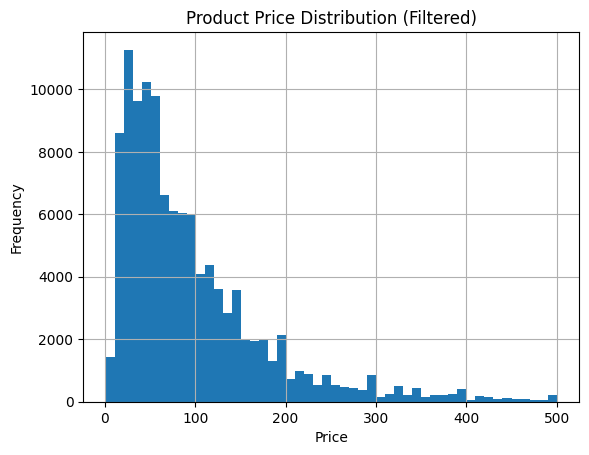

In [21]:
df[df['price'] < 500]['price'].hist(bins=50)
plt.title("Product Price Distribution (Filtered)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig(output_path + "price_distribution.png")
plt.show()

### Price Insight

- The original price distribution was highly skewed due to extreme outliers
- Most products are priced below 500
- A small number of high-priced products exist but are rare
- The platform mainly focuses on affordable products

<hr>

## Payment Value Distribution

In [22]:
df['payment_value'].describe()

count    118422.000000
mean        172.862531
std         268.265793
min           0.010000
25%          60.860000
50%         108.200000
75%         189.250000
max       13664.080000
Name: payment_value, dtype: float64

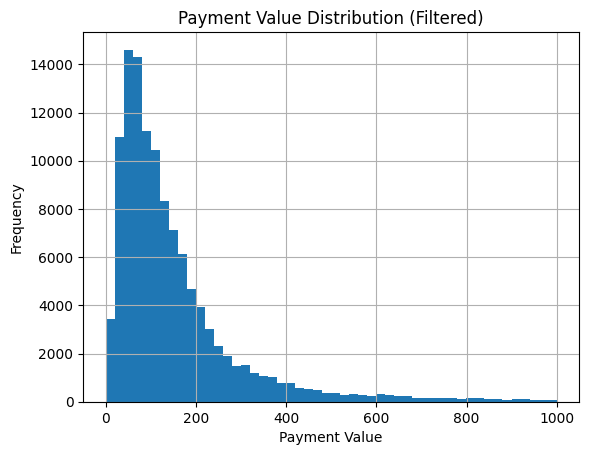

In [23]:
df[df['payment_value'] < 1000]['payment_value'].hist(bins=50)
plt.title("Payment Value Distribution (Filtered)")
plt.xlabel("Payment Value")
plt.ylabel("Frequency")
plt.savefig(output_path + "payment_distribution.png")
plt.show()

### Payment Insight

- Most transactions fall within lower payment ranges
- Few high-value transactions exist but are uncommon
- Revenue is primarily driven by a large number of small transactions

<hr>

## Order Per Customer 

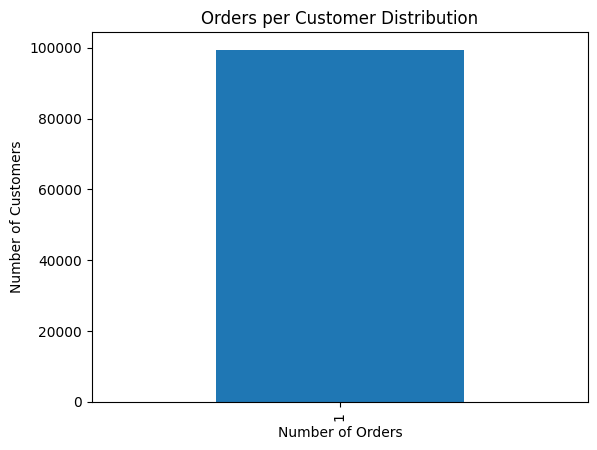

In [24]:
orders_per_customer = df.groupby('customer_id')['order_id'].nunique()

orders_per_customer.value_counts().head(10).plot(kind='bar')
plt.title("Orders per Customer Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.savefig(output_path + "orders_trend.png")
plt.show()

### Customer Behavior Insight

- Majority of customers place only 1 order
- Very few customers make repeat purchases
- Indicates extremely low customer retention
- Business relies heavily on new customer acquisition rather than repeat users

<hr>

## Order Over Time

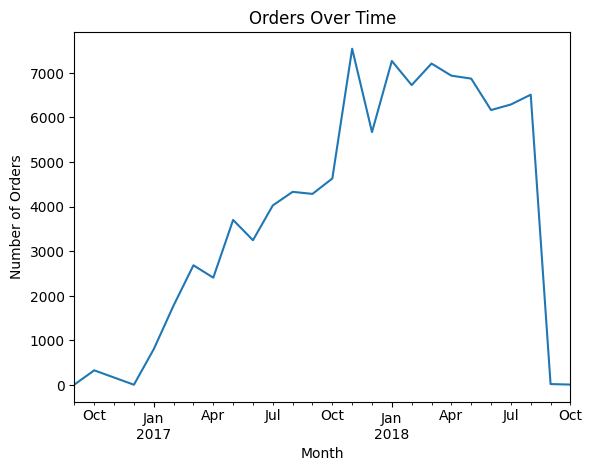

In [25]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

orders_trend = df.groupby('month')['order_id'].nunique()

orders_trend.plot()
plt.title("Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.savefig(output_path + "orders_trend.png")
plt.show()

### Order Trend Insight

- Order volume shows variation over time
- Certain months show higher activity indicating seasonal demand
- Growth or decline trends can be observed over the timeline

<hr>

## Delivery Time

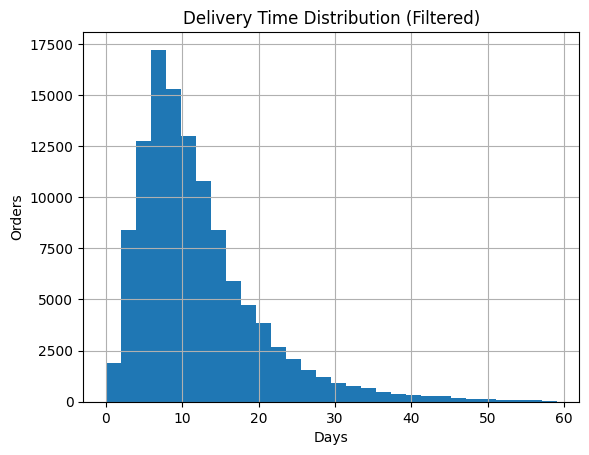

In [26]:
df['delivery_time'] = (
    pd.to_datetime(df['order_delivered_customer_date']) - 
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

df[df['delivery_time'] < 60]['delivery_time'].hist(bins=30)
plt.title("Delivery Time Distribution (Filtered)")
plt.xlabel("Days")
plt.ylabel("Orders")
plt.savefig(output_path + "delivery_time.png")
plt.show()

### Delivery Insight

- Most deliveries are completed within 5 to 20 days
- A few extreme delays exist but are rare
- Filtering helps reveal actual delivery performance
- Delivery efficiency is generally consistent for majority of orders

<hr>

## Late Delivery

In [27]:
df['estimated_delivery'] = pd.to_datetime(df['order_estimated_delivery_date'])

df['late_delivery'] = df['order_delivered_customer_date'] > df['estimated_delivery']

late_percentage = df['late_delivery'].mean() * 100

print(f"Late Delivery : {late_percentage} %")

Late Delivery : 7.622352821967778 %


### Delivery Performance Insight

- Approximately 7.6% of orders are delivered later than estimated
- Majority of deliveries are on time, indicating good logistics performance
- However, even a small percentage of delays can impact customer satisfaction
- Reducing late deliveries can improve trust and retention

<hr>

## Top Products 

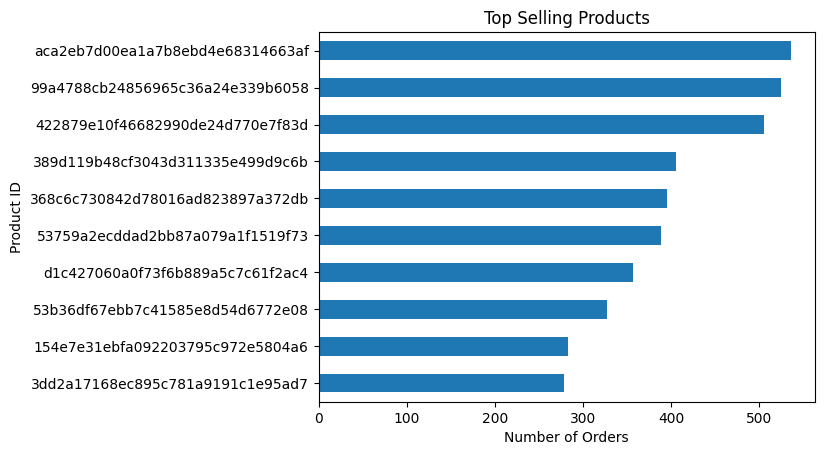

In [28]:
top_products = df['product_id'].value_counts().head(10)

top_products.sort_values().plot(kind='barh')
plt.title("Top Selling Products")
plt.xlabel("Number of Orders")
plt.ylabel("Product ID")
plt.savefig(output_path + "top_products.png")
plt.show()

### Product Insight

- A small number of products contribute significantly to total sales
- Demand is highly concentrated among top-performing products
- Indicates a skewed product distribution
- Opportunity to promote similar products to increase revenue

<hr>

## Customer Location

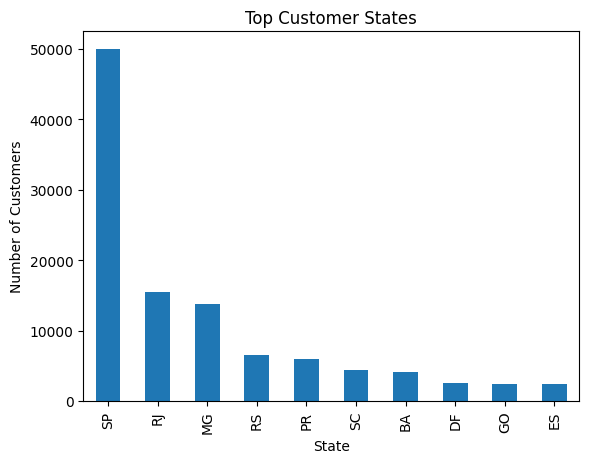

In [29]:
top_states = df['customer_state'].value_counts().head(10)

top_states.plot(kind='bar')
plt.title("Top Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.savefig(output_path + "price_distribution.png")
plt.savefig(output_path + "customer_states.png")
plt.show()

### Geographic Insight

- São Paulo (SP) dominates customer base by a large margin
- Other states like RJ and MG contribute significantly but are far behind
- Customer distribution is highly concentrated in a few regions
- Indicates strong regional demand patterns
- Marketing efforts can be focused on high-performing regions

<hr>

## Key Performance Indicators (KPIs)

- Total Revenue
- Total Orders
- Total Customers
- Average Order Value
- Late Delivery Percentage

In [30]:
kpis = {}

# Total Revenue
kpis['total_revenue'] = df['payment_value'].sum()

# Total Orders
kpis['total_orders'] = df['order_id'].nunique()

# Total Customers
kpis['total_customers'] = df['customer_id'].nunique()

# Average Order Value
kpis['average_order_value'] = kpis['total_revenue'] / kpis['total_orders']

# Late Delivery %
kpis['late_delivery_pct'] = df['late_delivery'].mean() * 100

# Convert to DataFrame
kpi_df = pd.DataFrame(list(kpis.items()), columns=['metric', 'value'])

# Save
kpi_df.to_csv(r"D:\Ayush\Learning\Projects\Ecommerce\outputs\kpi.csv", index=False)

kpi_df

,metric,value
0,total_revenue,2.047073e+07
1,total_orders,9.944100e+04
2,total_customers,9.944100e+04
3,average_order_value,2.058580e+02
4,late_delivery_pct,7.622353e+00


<hr>

## Final Business Insights

- The business is driven by high-volume, low-value transactions
- Customer retention is extremely low, with most users making only one purchase
- Orders have grown over time, showing increasing platform adoption
- Delivery performance is generally good, but delays still exist (~7.6%)
- Sales are concentrated among a limited number of products
- Customer base is heavily concentrated in specific regions (especially SP)


## Recommendations

- Improve customer retention strategies (loyalty programs, offers)
- Optimize delivery operations to reduce delays
- Promote top-performing products and similar categories
- Focus marketing on high-demand regions
- Encourage repeat purchases through personalized engagement